# Module 5 · Is the shift even real over time?

**Trend · seasonality · stationarity — putting a day-over-day move in perspective.**

By the end of this module you can answer, on demand: *"Metric X moved yesterday —
do I react, or is that just Tuesday?"* You will judge the latest day against
(a) the **month-wide ±2σ band** and (b) its **own day-of-week baseline**, then run a
light **regime-break** test. That last test doubles as the guard on Module 4:
if the recent regime has broken, the historical prior you were borrowing strength
from is no longer safe to use.

## 1 · The panicked Slack message

> **@channel** 🔴 **Bing CTR was 44% yesterday — it was 46% last Saturday. Are we
> losing Bing?? Do we pause the campaign?**

Before anyone touches a budget, the analyst's job is one question:

> **Is this a real move, or normal day-to-day variation?**

Two traps hide in that Slack message:

1. **One low day is not a trend.** A single day bounces around inside a noise band
   every week — you need to know how *wide* that band is before calling anything.
2. **Weekdays are not weekends.** If CTR is naturally higher on Saturdays, then
   comparing *this* Saturday to *last* Saturday is fine — but comparing a Saturday
   to a Wednesday is comparing apples to oranges. Seasonality has to be removed
   before a "drop" means anything.

We answer it in the four-beat loop: **by hand → extract → validate → automate.**

## 2 · By hand — build the series and the band

In [1]:
import sys
sys.path.insert(0, "/home/am/projects/natural-intelligence/new_workshop/.claude/skills/_lib")
import ni_core as C

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11,
})

# Raw click-out grain; `clicked` is True where a partner was clicked.
df = C.load_clickouts()
df["clicked_i"] = df["clicked"].astype(int)          # 0/1 so a daily mean == CTR

bing = df[df["channel"] == "Bing"].copy()
print(f"Bing rows: {len(bing):,}   dates: "
      f"{bing['date'].min().date()} → {bing['date'].max().date()}")

Bing rows: 37,376   dates: 2026-03-01 → 2026-05-30


In [2]:
# Daily CTR = fraction of Bing rows that day carrying a click-out.
ctr = C.daily_series(bing, "clicked_i", how="rate")   # index = date, value = CTR

month_mean = ctr.mean()
month_std  = ctr.std(ddof=1)
band_lo, band_hi = month_mean - 2 * month_std, month_mean + 2 * month_std

latest_date = ctr.index[-1]
latest      = ctr.iloc[-1]

print(f"days of history : {len(ctr)}")
print(f"latest day      : {latest_date.date()}  ({bing.loc[bing.date==latest_date,'day_of_week'].iloc[0]})")
print(f"latest CTR      : {latest:6.2%}")
print(f"month mean      : {month_mean:6.2%}")
print(f"month std       : {month_std:6.2%}")
print(f"±2σ band        : [{band_lo:.2%}, {band_hi:.2%}]")
print(f"latest inside band? {band_lo <= latest <= band_hi}")

days of history : 91
latest day      : 2026-05-30  (Sat)
latest CTR      : 44.22%
month mean      : 42.36%
month std       :  3.09%
±2σ band        : [36.18%, 48.54%]
latest inside band? True


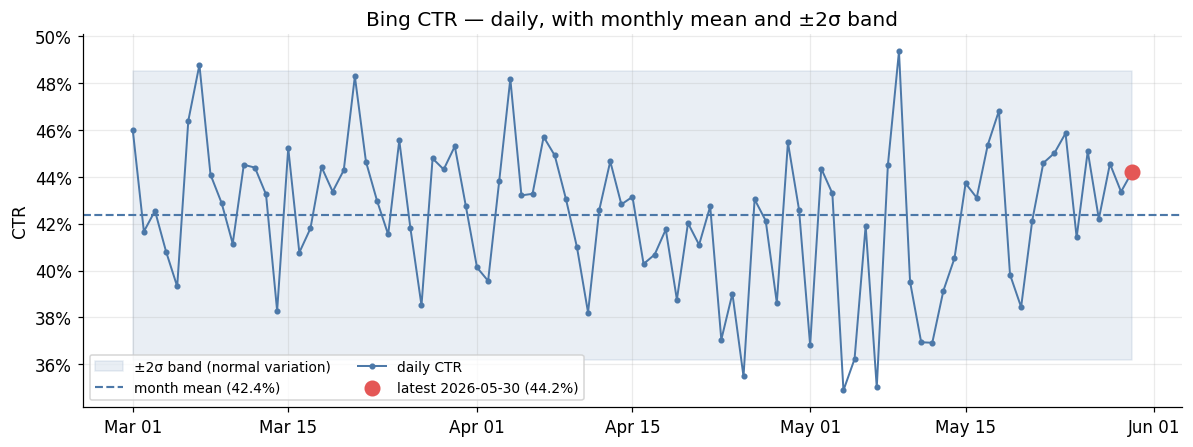

The red dot (latest day) sits comfortably inside the shaded band — no single-day alarm.


In [3]:
# --- Chart 1: the daily CTR series with its monthly mean and ±2σ band --------
fig, ax = plt.subplots()
ax.fill_between(ctr.index, band_lo, band_hi, color="#4C78A8", alpha=0.12,
                label="±2σ band (normal variation)")
ax.axhline(month_mean, color="#4C78A8", lw=1.4, ls="--", label=f"month mean ({month_mean:.1%})")
ax.plot(ctr.index, ctr.values, color="#4C78A8", lw=1.3, marker="o", ms=3, label="daily CTR")
ax.scatter([latest_date], [latest], color="#E45756", zorder=5, s=90,
           label=f"latest {latest_date.date()} ({latest:.1%})")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Bing CTR — daily, with monthly mean and ±2σ band")
ax.set_ylabel("CTR"); ax.legend(loc="lower left", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

print("The red dot (latest day) sits comfortably inside the shaded band — "
      "no single-day alarm.")

### Seasonality: is a raw day-vs-last-week comparison even fair?

The band above treats every day the same. But CTR has a **weekly rhythm** — if
weekends run hotter than weekdays, then part of any "drop" is just *which day it
is*. Let's build the **day-of-week baseline** (mean CTR per weekday) and see.

In [4]:
# Per-day-of-week mean & std of the daily CTR series.
base = C.dow_baseline(bing, "clicked_i")     # index Mon..Sun, cols dow_mean/dow_std/count
print(base.assign(dow_mean=lambda d: (d.dow_mean*100).round(2),
                  dow_std =lambda d: (d.dow_std *100).round(2)))

wk = bing.assign(w=bing["is_weekend"])
weekday_ctr = bing.loc[~bing.is_weekend, "clicked_i"].mean()
weekend_ctr = bing.loc[ bing.is_weekend, "clicked_i"].mean()
print(f"\nweekday CTR : {weekday_ctr:.2%}")
print(f"weekend CTR : {weekend_ctr:.2%}")
print(f"weekend − weekday gap: {(weekend_ctr-weekday_ctr)*100:+.2f} pts  "
      "→ seasonality is real; compare like-for-like weekdays only.")

             dow_mean  dow_std  count
day_of_week                          
Mon             41.98     3.20     13
Tue             41.24     2.80     13
Wed             42.57     2.39     13
Thu             41.05     2.82     13
Fri             42.31     2.84     13
Sat             43.83     4.41     13
Sun             43.53     2.24     13

weekday CTR : 41.84%
weekend CTR : 43.74%
weekend − weekday gap: +1.90 pts  → seasonality is real; compare like-for-like weekdays only.


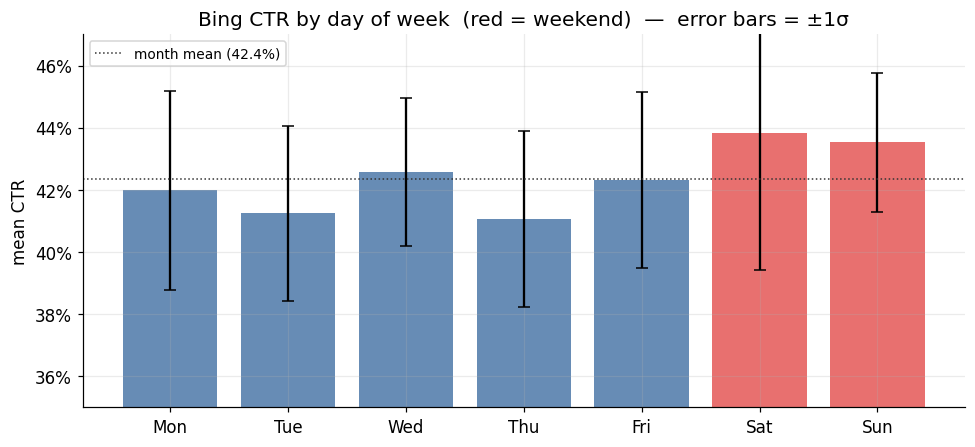

Saturday & Sunday sit visibly above the mid-week bars. A Saturday should be judged against OTHER Saturdays, not against last Wednesday.


In [5]:
# --- Chart 2: day-of-week bars, weekdays vs weekend colour-coded -------------
order   = list(base.index)                       # Mon..Sun
means   = base["dow_mean"].values
stds    = base["dow_std"].values
is_wknd = [d in ("Sat", "Sun") for d in order]
colors  = ["#E45756" if w else "#4C78A8" for w in is_wknd]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(order, means, yerr=stds, capsize=4, color=colors, alpha=0.85)
ax.axhline(month_mean, color="#333", lw=1, ls=":", label=f"month mean ({month_mean:.1%})")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0.35, 0.47)
ax.set_title("Bing CTR by day of week  (red = weekend)  —  error bars = ±1σ")
ax.set_ylabel("mean CTR"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Saturday & Sunday sit visibly above the mid-week bars. A Saturday should be "
      "judged against OTHER Saturdays, not against last Wednesday.")

So the latest day is a **Saturday**. The fair yardstick is the *Saturday
baseline*, not the calendar-yesterday. Let's check the latest day against its own
day-of-week baseline.

In [6]:
dow_latest = bing.loc[bing.date == latest_date, "day_of_week"].iloc[0]
dow_mean   = base.loc[dow_latest, "dow_mean"]
dow_std    = base.loc[dow_latest, "dow_std"]
dow_within = abs(latest - dow_mean) <= 2 * dow_std

print(f"latest day is a {dow_latest}")
print(f"{dow_latest} baseline : {dow_mean:.2%}  ± {dow_std:.2%}")
print(f"latest CTR      : {latest:.2%}")
print(f"within its own day-of-week ±2σ? {dow_within}")
print("→ Judged against other Saturdays, the latest day is entirely ordinary.")

latest day is a Sat
Sat baseline : 43.83%  ± 4.41%
latest CTR      : 44.22%
within its own day-of-week ±2σ? True
→ Judged against other Saturdays, the latest day is entirely ordinary.


### A light regime-break test — has the *recent* level shifted?

One day being normal doesn't rule out a slow drift. So we ask a second question:
is the **last 7 days' mean** unusually far from the **prior period's** distribution?

We compute a z-score: how many standard-errors the recent mean sits from the prior
mean. `|z| > 2` ⇒ the regime has plausibly shifted (and any historical prior is
suspect). This is deliberately light — a tripwire, not a full change-point model.

In [7]:
recent_days = 7
recent = ctr.iloc[-recent_days:]
prior  = ctr.iloc[:-recent_days]

se_prior = prior.std(ddof=1) / np.sqrt(len(recent))    # SE of the recent-window mean
regime_z = (recent.mean() - prior.mean()) / se_prior
regime_break = abs(regime_z) > 2

print(f"prior period    : {prior.index[0].date()} → {prior.index[-1].date()}  "
      f"({len(prior)} days), mean {prior.mean():.2%}")
print(f"recent {recent_days} days   : {recent.index[0].date()} → {recent.index[-1].date()}, "
      f"mean {recent.mean():.2%}")
print(f"regime z        : {regime_z:+.2f}")
print(f"regime break?   : {regime_break}   (|z| > 2 would flag a shift)")

prior period    : 2026-03-01 → 2026-05-23  (84 days), mean 42.24%
recent 7 days   : 2026-05-24 → 2026-05-30, mean 43.82%
regime z        : +1.32
regime break?   : False   (|z| > 2 would flag a shift)


## 3 · Extract — the same thing in one call

Everything above — band, day-of-week baseline, regime z — is packaged in
`C.trend_check(...)`. We run it and **assert** it reproduces the by-hand numbers,
so we trust the library exactly because we already did the arithmetic ourselves.

In [8]:
tc = C.trend_check(bing, "clicked_i", how="rate", recent_days=7)

for k in ["latest_date", "dow", "latest", "month_mean", "band_lo", "band_hi",
          "within_band", "dow_mean", "dow_std", "dow_within",
          "recent_mean", "prior_mean", "regime_z", "regime_break"]:
    v = tc[k]
    print(f"{k:14s}: {v:.4f}" if isinstance(v, float) else f"{k:14s}: {v}")

latest_date   : 2026-05-30
dow           : Sat
latest        : 0.4422
month_mean    : 0.4236
band_lo       : 0.3618
band_hi       : 0.4854
within_band   : True
dow_mean      : 0.4383
dow_std       : 0.0441
dow_within    : True
recent_mean   : 0.4382
prior_mean    : 0.4224
regime_z      : 1.3235
regime_break  : False


In [9]:
# Assert the library matches our by-hand computation to floating-point tolerance.
assert tc["latest_date"] == str(latest_date.date())
assert np.isclose(tc["latest"],     latest)
assert np.isclose(tc["month_mean"], month_mean)
assert np.isclose(tc["band_lo"],    band_lo)
assert np.isclose(tc["band_hi"],    band_hi)
assert tc["within_band"] is True or tc["within_band"] == True
assert np.isclose(tc["dow_mean"],   dow_mean)
assert np.isclose(tc["regime_z"],   regime_z)
assert tc["regime_break"] == regime_break == False

# And a couple of headline sanity checks against the module's verified targets.
assert abs(tc["latest"]     - 0.442) < 0.005          # ~44.2%
assert abs(tc["month_mean"] - 0.424) < 0.005          # ~42.4%
assert abs(tc["band_lo"]    - 0.362) < 0.005          # ~36.2%
assert abs(tc["band_hi"]    - 0.485) < 0.005          # ~48.5%

print("✅ C.trend_check reproduces every by-hand number.")
print(f"   latest {tc['latest']:.2%}  band [{tc['band_lo']:.2%}, {tc['band_hi']:.2%}]  "
      f"within={tc['within_band']}  regime_z={tc['regime_z']:+.2f}  break={tc['regime_break']}")

✅ C.trend_check reproduces every by-hand number.
   latest 44.22%  band [36.18%, 48.54%]  within=True  regime_z=+1.32  break=False


## 4 · Validate — the money cell

A detector is only trustworthy if it does **both** jobs:

- **(a) stays quiet on noise** — a genuinely normal recent day gets "no reaction
  needed", so we don't cry wolf every Monday.
- **(b) fires on a real break** — when the level actually shifts, `regime_break`
  flips to `True` *and* the latest day falls outside the band.

We test both. For (b) we **inject** a synthetic break: scale the last 10 days of
Bing CTR down to ~60% of normal (a real, ~40% collapse) — seeded, so it's
reproducible — and re-run the identical `trend_check`.

In [10]:
# --- (a) The real, un-doctored latest day: does the detector stay quiet? ------
verdict = "🔴 REACT — regime break" if tc["regime_break"] else "🟢 no reaction needed"
band_ok = "inside band" if tc["within_band"] else "OUTSIDE band"
print("CHECK (a) — genuine recent day (no injection)")
print(f"  latest {tc['latest']:.2%} is {band_ok}  [{tc['band_lo']:.2%}, {tc['band_hi']:.2%}]")
print(f"  regime_z {tc['regime_z']:+.2f}  →  {verdict}")
assert tc["within_band"] and not tc["regime_break"]
print("  ✅ Detector correctly stays QUIET on normal variation.\n")

CHECK (a) — genuine recent day (no injection)
  latest 44.22% is inside band  [36.18%, 48.54%]
  regime_z +1.32  →  🟢 no reaction needed
  ✅ Detector correctly stays QUIET on normal variation.



In [11]:
# --- (b) Inject a genuine regime break into the last 10 days ------------------
# clicked_i is 0/1, so "×0.6" means: keep each recent click with prob 0.6
# (drop ~40%), which scales the daily CTR to ~60% of normal. Seeded → reproducible.
rng = np.random.default_rng(42)
broken = bing.copy()

cut = ctr.index[-10]                                   # first of the last 10 days
recent_clicks = broken.index[(broken.date >= cut) & (broken.clicked_i == 1)]
keep = rng.random(len(recent_clicks)) < 0.6
broken.loc[recent_clicks[~keep], "clicked_i"] = 0      # drop ~40% of recent clicks

tcb = C.trend_check(broken, "clicked_i", how="rate", recent_days=7)

print(f"injected break from {cut.date()} onward (last 10 days scaled to ~60%)")
print(f"  latest CTR   : {tcb['latest']:.2%}   (was {tc['latest']:.2%})")
print(f"  ±2σ band     : [{tcb['band_lo']:.2%}, {tcb['band_hi']:.2%}]")
print(f"  within band? : {tcb['within_band']}   (was {tc['within_band']})")
print(f"  regime_z     : {tcb['regime_z']:+.2f}   (was {tc['regime_z']:+.2f})")
print(f"  regime_break?: {tcb['regime_break']}   (was {tc['regime_break']})")

assert tcb["regime_break"] is True or tcb["regime_break"] == True
assert not tcb["within_band"]
print("\n  ✅ Detector FIRES on the injected break: regime_break=True AND latest is "
      "outside the band.")

injected break from 2026-05-21 onward (last 10 days scaled to ~60%)
  latest CTR   : 24.49%   (was 44.22%)
  ±2σ band     : [28.63%, 52.19%]
  within band? : False   (was True)
  regime_z     : -9.48   (was +1.32)
  regime_break?: True   (was False)

  ✅ Detector FIRES on the injected break: regime_break=True AND latest is outside the band.


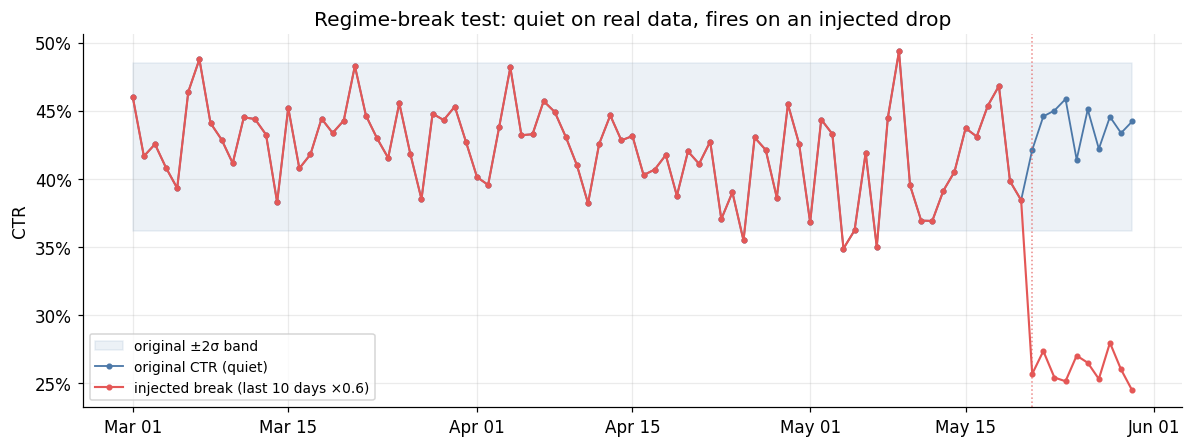

Red line collapses below the band after the dotted cutoff — exactly the signal trend_check turns into regime_break=True.


In [12]:
# --- Chart 3: original vs injected-break series, side by side ----------------
ctr_b = C.daily_series(broken, "clicked_i", how="rate")

fig, ax = plt.subplots()
ax.fill_between(ctr.index, band_lo, band_hi, color="#4C78A8", alpha=0.10,
                label="original ±2σ band")
ax.plot(ctr.index,   ctr.values,   color="#4C78A8", lw=1.2, marker="o", ms=3,
        label="original CTR (quiet)")
ax.plot(ctr_b.index, ctr_b.values, color="#E45756", lw=1.4, marker="o", ms=3,
        label="injected break (last 10 days ×0.6)")
ax.axvline(cut, color="#E45756", ls=":", lw=1, alpha=0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Regime-break test: quiet on real data, fires on an injected drop")
ax.set_ylabel("CTR"); ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

print("Red line collapses below the band after the dotted cutoff — exactly the "
      "signal trend_check turns into regime_break=True.")

## 5 · Close — `/trend-check` automates this

Everything in this notebook is one command:

```
/trend-check channel=Bing metric=CTR
```

It builds the daily series, draws the ±2σ band, computes the day-of-week baseline,
runs the regime tripwire, and returns the same verdict — *react* or *no reaction
needed* — with a seeded, auditable report.

**What to carry out of the room**

- **One low day isn't a trend.** Judge it against the ±2σ band before reacting —
  our latest Bing day (44.2%) sat well inside `[36.2%, 48.5%]`.
- **Weekdays differ — don't compare across them.** Weekends run hotter; compare a
  Saturday to other Saturdays. Seasonality is a real effect, not noise.
- **The regime-break test is the guard on Module 4.** `/bayesian-update` leans on a
  historical prior. If `trend_check` flags a regime break, that prior is **stale** —
  the history no longer describes today, and borrowing from it would mislead. A
  green regime check is what makes the Module-4 prior safe to use.
- A good detector is quiet on noise **and** loud on a real break — we proved both.